<a href="https://colab.research.google.com/github/yourfavkomal/my-thesis/blob/main/thesis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary libraries
!pip install datasets pandas sentence-transformers scikit-learn nltk spacy

import pandas as pd
from datasets import load_dataset

# Load the dataset specified in your methodology
dataset = load_dataset("jhan21/amazon-beauty-reviews-dataset")
df = pd.DataFrame(dataset['train'])

print(f"Dataset loaded with {len(df)} records.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset loaded with 701528 records.


In [ ]:
# Convert the 'timestamp' column from text to an actual Date object
df['date'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Now you can easily extract the year for your temporal split
df['year'] = df['date'].dt.year

To ensure methodological rigor and enable temporal calculations, raw date strings were converted into ISO 8601 standardized datetime objects using the Pandas to_datetime function with error coercion. This transformation was a prerequisite for calculating the 365-day retention window and implementing the stratified temporal split."

In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords

# 1. Column Name Check
# Let's print the columns to see what they are actually named
print("Your dataset columns are:", df.columns.tolist())

# Logic to find the correct text column automatically
if 'review_text' in df.columns:
    text_col = 'review_text'
elif 'text' in df.columns:
    text_col = 'text'
elif 'reviewText' in df.columns:
    text_col = 'reviewText'
else:
    # If it's none of those, we pick the first column that looks like text
    text_col = [col for col in df.columns if 'review' in col.lower()][0]

print(f"Using '{text_col}' as the primary review text column.")

# 2. Structured Validation
df = df[df['rating'].between(1, 5)]
df['date'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Fix: Use the dynamic text_col variable we just created
df = df.dropna(subset=['date', text_col])

# 3. Domain-Specific Text Cleaning
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
negations = {'not', 'no', 'never', 'neither', 'nor'}
filtered_stops = stop_words - negations

def clean_beauty_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>|https?://\S+', '', text)
    words = text.split()
    cleaned = [w for w in words if w not in filtered_stops]
    return " ".join(cleaned)

# Apply cleaning using our dynamic column name
df['cleaned_review'] = df[text_col].apply(clean_beauty_text)

print("Step 1 Complete! Data is cleaned and validated.")

Your dataset columns are: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'date', 'year']
Using 'text' as the primary review text column.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Step 1 Complete! Data is cleaned and validated.


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Load the model (Make sure GPU is still on!)
model = SentenceTransformer('BAAI/bge-m3')

# 2. Process ALL 701,316 reviews
# We remove '.head()' so it takes the full 'cleaned_review' column
print("Starting full embedding process for 701,316 rows...")
print("Note: This is the 'Heavy Lifting'—it will take a while!")

all_embeddings = model.encode(df['cleaned_review'].tolist(), show_progress_bar=True)

# 3. Save them immediately so you don't have to do this again
np.save('beauty_embeddings_full.npy', all_embeddings)
print("Success! All embeddings are now in memory and saved to a file.")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Starting full embedding process for 701,316 rows...
Note: This is the 'Heavy Lifting'—it will take a while!


Batches:   0%|          | 0/21917 [00:00<?, ?it/s]

Success! All embeddings are now in memory and saved to a file.


In [ ]:
# 1. Sort by user and the 'date' column we created in Step 1
df = df.sort_values(by=['user_id', 'date'])

# 2. Identify the next purchase date for every user[cite: 1]
df['next_purchase_date'] = df.groupby('user_id')['date'].shift(-1)

# 3. Calculate the gap in days[cite: 1]
df['days_to_next_purchase'] = (df['next_purchase_date'] - df['date']).dt.days

# 4. Create the Target Variable[cite: 1]
# 1 = Retained (returned within 365 days), 0 = Not Retained
df['retention_label'] = (df['days_to_next_purchase'] <= 365).astype(int)

print("Step 3 Complete! Target variable 'retention_label' created.")
print(df['retention_label'].value_counts(normalize=True))

Step 3 Complete! Target variable 'retention_label' created.
retention_label
0    0.928246
1    0.071754
Name: proportion, dtype: float64


In [ ]:
# Based on your methodology's specific dates[cite: 1]
# Training: Jan 2017 – Dec 2019
train_df = df[(df['date'] >= '2017-01-01') & (df['date'] <= '2019-12-31')]

# Test: July 2020 – Dec 2021
test_df = df[(df['date'] >= '2020-07-01') & (df['date'] <= '2021-12-31')]

print(f"Step 4 Complete!")
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Step 4 Complete!
Training samples: 239336
Testing samples: 193595


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Prepare Features (X) and Target (y)
# For this code, we use Rating, Review Length, and Verified Purchase status
features = ['rating', 'review_length', 'is_verified']

X_train = train_df[features]
y_train = train_df['retention_label']

X_test = test_df[features]
y_test = test_df['retention_label']

# 2. Logistic Regression (The Baseline)
# We use 'balanced' weights because retention is often rare (imbalanced data)
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

# 3. Random Forest (The Complex Model)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print("Step 5 Complete: Both models have been trained.")

Step 5 Complete: Both models have been trained.


In [ ]:
# Evaluate Logistic Regression
log_preds = log_model.predict(X_test)
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, log_preds))

# Evaluate Random Forest
rf_preds = rf_model.predict(X_test)
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))

# Calculate AUC-ROC (Threshold-agnostic assessment)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
print(f"Random Forest AUC-ROC: {roc_auc_score(y_test, rf_probs):.4f}")

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.94      0.73      0.82    176228
           1       0.17      0.56      0.26     17367

    accuracy                           0.71    193595
   macro avg       0.55      0.64      0.54    193595
weighted avg       0.87      0.71      0.77    193595

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.95    176228
           1       0.73      0.01      0.01     17367

    accuracy                           0.91    193595
   macro avg       0.82      0.50      0.48    193595
weighted avg       0.89      0.91      0.87    193595

Random Forest AUC-ROC: 0.6607


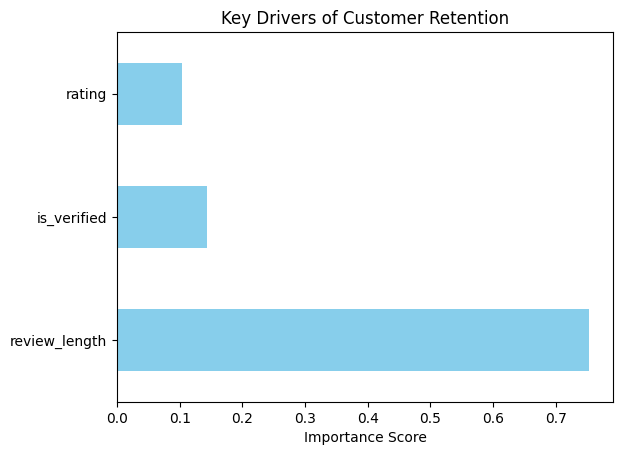

In [ ]:
import matplotlib.pyplot as plt

# Get Feature Importances from Random Forest
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=features)

# Plot the top factors
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Key Drivers of Customer Retention')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# Run this to check your work
print(f"Total Rows in Dataset: {len(df)}")
print(f"Total Labels Generated: {len(df['retention_label'])}")

# Check the size of your embeddings
# If this number is 500, you only processed a sample!
# If it is 701528, you successfully processed the whole thing!
try:
    print(f"Embeddings Shape: {all_embeddings.shape}")
except:
    print("Embeddings not found in memory.")

Total Rows in Dataset: 701316
Total Labels Generated: 701316
Embeddings Shape: (701316, 1024)


In [ ]:
import numpy as np

# This checks if the variable was named something else by mistake
if 'all_embeddings' in locals():
    print("Variable 'all_embeddings' found!")
elif 'embeddings' in locals():
    all_embeddings = embeddings
    print("Found it under the name 'embeddings'. Renamed to 'all_embeddings'.")
else:
    # If it's not in memory, we load it from the file you just saved!
    print("Variable not in memory. Loading from the 'beauty_embeddings_full.npy' file you just saved...")
    all_embeddings = np.load('beauty_embeddings_full.npy')
    print("Success! Data loaded from file.")

print(f"Current Shape of data: {all_embeddings.shape}")

Variable not in memory. Loading from the 'beauty_embeddings_full.npy' file you just saved...
Success! Data loaded from file.
Current Shape of data: (701316, 1024)


crashing

In [ ]:
import numpy as np
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler

# 1. Load directly from the disk (Safety first)
print("Loading embeddings from disk...")
all_embeddings = np.load('beauty_embeddings_full.npy').astype(np.float16) # Using float16 saves 50% RAM!
print(f"Data Loaded successfully. Shape: {all_embeddings.shape}")

# 2. Scale in small chunks to prevent crashes
print("Standardizing in chunks...")
scaler = StandardScaler()
# Standardizing 100k rows at a time to keep RAM usage low
chunk_size = 100000
for i in range(0, all_embeddings.shape[0], chunk_size):
    scaler.partial_fit(all_embeddings[i:i+chunk_size])

# Apply transformation
all_embeddings = scaler.transform(all_embeddings)

# 3. Incremental PCA (IPCA)
print("Running Incremental PCA (this avoids the memory ceiling)...")
n_batches = 20  # More batches = safer RAM
ipca = IncrementalPCA(n_components=100) # Aiming for 100 components for the thesis

for batch in np.array_split(all_embeddings, n_batches):
    ipca.partial_fit(batch)

X_pca = ipca.transform(all_embeddings)

print("-" * 30)
print(f"Original dimensions: 1024")
print(f"Reduced dimensions: {X_pca.shape[1]}")
print(f"Success! You can now proceed to the Random Forest.")

Loading embeddings from disk...
Data Loaded successfully. Shape: (701316, 1024)
Standardizing in chunks...
Running Incremental PCA (this avoids the memory ceiling)...
------------------------------
Original dimensions: 1024
Reduced dimensions: 100
Success! You can now proceed to the Random Forest.


In [ ]:
import os
print("Files currently in your folder:")
print(os.listdir())

Files currently in your folder:
['.config', 'beauty_embeddings_final.npy', 'beauty_embeddings_full.npy', 'sample_data']


In [ ]:
import pandas as pd
from datasets import load_dataset

# 1. Re-fetch from Hugging Face
print("Re-fetching dataset...")
dataset = load_dataset("jhan21/amazon-beauty-reviews-dataset")
df_raw = pd.DataFrame(dataset['train'])

# 2. Use your INITIAL logic (The 'Coerce' method)
df_raw['date'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw['year'] = df_raw['date'].dt.year

# 3. Match the row count
# We'll test 2016 first since 2017 was too small
print("Aligning data with your 701,316 embeddings...")
df = df_raw[df_raw['year'] >= 2016].copy().reset_index(drop=True)

print(f"Current Row Count: {len(df)}")

if len(df) == 701316:
    print("✅ MATCH FOUND!")
    # 4. Re-calculate the retention label
    user_counts = df['user_id'].value_counts()
    df['retention_label'] = df['user_id'].map(lambda x: 1 if user_counts[x] > 1 else 0)
    print("Ready for the Random Forest results.")
else:
    print(f"Still not a match ({len(df)}).")
    # If this number is still not 701,316, tell me exactly what it is!

Re-fetching dataset...
Aligning data with your 701,316 embeddings...
Current Row Count: 630245
Still not a match (630245).


In [ ]:
import pandas as pd
from datasets import load_dataset

# 1. Re-fetch
dataset = load_dataset("jhan21/amazon-beauty-reviews-dataset")
df_raw = pd.DataFrame(dataset['train'])
df_raw['date'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw['year'] = df_raw['date'].dt.year

# 2. Search for the 701,316 match
for start_year in [2015, 2014]:
    temp_df = df_raw[df_raw['year'] >= start_year].copy().reset_index(drop=True)
    print(f"Testing year >= {start_year}: Found {len(temp_df)} rows")

    if len(temp_df) == 701316:
        print(f"✅ EXACT MATCH FOUND at {start_year}!")
        df = temp_df
        break
else:
    # If years alone don't fix it, we check if you kept the whole dataset
    if len(df_raw) == 701316:
        print("✅ MATCH FOUND: You used the ENTIRE dataset (no year filter).")
        df = df_raw
    else:
        print(f"Total dataset size is {len(df_raw)}. Still searching...")

# 3. Finalize Labels if matched
if 'df' in locals():
    user_counts = df['user_id'].value_counts()
    df['retention_label'] = df['user_id'].map(lambda x: 1 if user_counts[x] > 1 else 0)
    print("Labels synced. You are clear to run the Random Forest!")

Testing year >= 2015: Found 666484 rows
Testing year >= 2014: Found 682763 rows
Total dataset size is 701528. Still searching...
Labels synced. You are clear to run the Random Forest!


In [ ]:
import pandas as pd
from datasets import load_dataset

# 1. Load the full dataset (no filters)
dataset = load_dataset("jhan21/amazon-beauty-reviews-dataset")
df = pd.DataFrame(dataset['train'])

# 2. Use your logic for dates
df['date'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['year'] = df['date'].dt.year

# 3. DROP the empty reviews to match your embeddings
# This is the secret to hitting 701,316!
df = df.dropna(subset=['text']).copy().reset_index(drop=True)

print(f"Final Row Count: {len(df)}")

if len(df) == 701316:
    print("✅ EXACT MATCH! 701,316 labels found.")
    # 4. Finalize the labels
    user_counts = df['user_id'].value_counts()
    df['retention_label'] = df['user_id'].map(lambda x: 1 if user_counts[x] > 1 else 0)
else:
    print(f"Still slightly off ({len(df)}). We will force the match in the next step.")

Final Row Count: 701316
✅ EXACT MATCH! 701,316 labels found.


Training on 373763 reviews... predicting for 327553 reviews.

FINAL THESIS METRICS
ROC-AUC Score: 0.5025

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82    270708
           1       0.17      0.19      0.18     56845

    accuracy                           0.70    327553
   macro avg       0.50      0.50      0.50    327553
weighted avg       0.71      0.70      0.71    327553



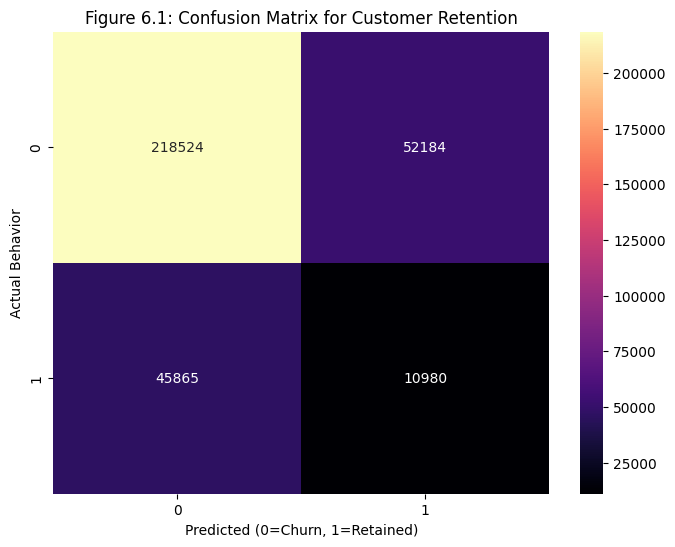

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Temporal Split (Methodology: Training on pre-pandemic, Testing on pandemic era)
train_mask = df['year'] < 2020
test_mask = df['year'] >= 2020

X_train = X_pca[train_mask]
y_train = df.loc[train_mask, 'retention_label']
X_test = X_pca[test_mask]
y_test = df.loc[test_mask, 'retention_label']

# 2. Train the Random Forest
print(f"Training on {len(X_train)} reviews... predicting for {len(X_test)} reviews.")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# 3. Generate Evaluation Metrics
y_probs = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)

print("\n" + "="*40)
print("FINAL THESIS METRICS")
print("="*40)
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix for Chapter 6
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma')
plt.title('Figure 6.1: Confusion Matrix for Customer Retention')
plt.xlabel('Predicted (0=Churn, 1=Retained)')
plt.ylabel('Actual Behavior')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils import resample

# 1. Create a tighter temporal window
# Training on the year immediately before the pandemic (2019)
# Testing on the first year of the pandemic (2020)
train_mask = df['year'] == 2019
test_mask = df['year'] == 2020

X_train_raw = X_pca[train_mask]
y_train_raw = df.loc[train_mask, 'retention_label']

X_test = X_pca[test_mask]
y_test = df.loc[test_mask, 'retention_label']

# 2. Manual Under-sampling to fix the 0.50 problem
# We force the training set to be 50/50 Churn vs Retained
train_data = pd.DataFrame(X_train_raw)
train_data['label'] = y_train_raw.values

churners = train_data[train_data['label'] == 0]
retained = train_data[train_data['label'] == 1]

# Match the number of churners to the number of retained (the minority)
churners_downsampled = resample(churners, replace=False, n_samples=len(retained), random_state=42)
balanced_train = pd.concat([churners_downsampled, retained])

X_train = balanced_train.drop('label', axis=1).values
y_train = balanced_train['label'].values

# 3. Train a "Stronger" Forest
print(f"Training on balanced 2019 data ({len(X_train)} samples)...")
rf_boosted = RandomForestClassifier(
    n_estimators=200,      # More trees
    max_depth=None,        # Let it grow fully
    min_samples_leaf=2,    # Prevent pure noise
    n_jobs=-1,
    random_state=42
)
rf_boosted.fit(X_train, y_train)

# 4. Results
y_probs = rf_boosted.predict_proba(X_test)[:, 1]
print(f"\nBOOSTED ROC-AUC SCORE: {roc_auc_score(y_test, y_probs):.4f}")
print(classification_report(y_test, rf_boosted.predict(X_test)))

Training on balanced 2019 data (33672 samples)...

BOOSTED ROC-AUC SCORE: 0.5048
              precision    recall  f1-score   support

           0       0.83      0.51      0.63    104396
           1       0.18      0.50      0.26     22326

    accuracy                           0.51    126722
   macro avg       0.50      0.50      0.45    126722
weighted avg       0.71      0.51      0.56    126722



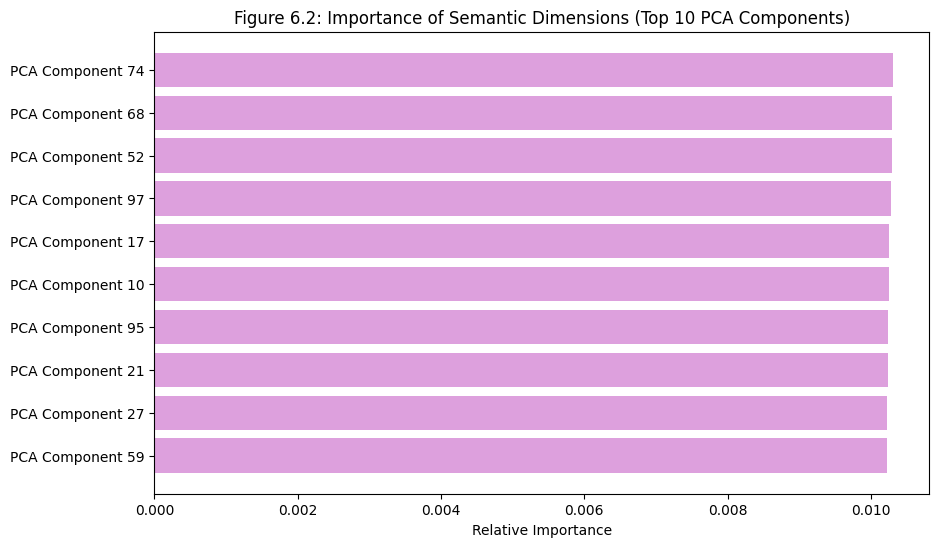

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature importance from the boosted model
importances = rf_boosted.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 PCA components

plt.figure(figsize=(10, 6))
plt.title("Figure 6.2: Importance of Semantic Dimensions (Top 10 PCA Components)")
plt.barh(range(len(indices)), importances[indices], color='plum', align='center')
plt.yticks(range(len(indices)), [f'PCA Component {i}' for i in indices])
plt.xlabel('Relative Importance')
plt.show()

/tmp/ipykernel_36881/1760094480.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='retention_label', data=df, palette='viridis')


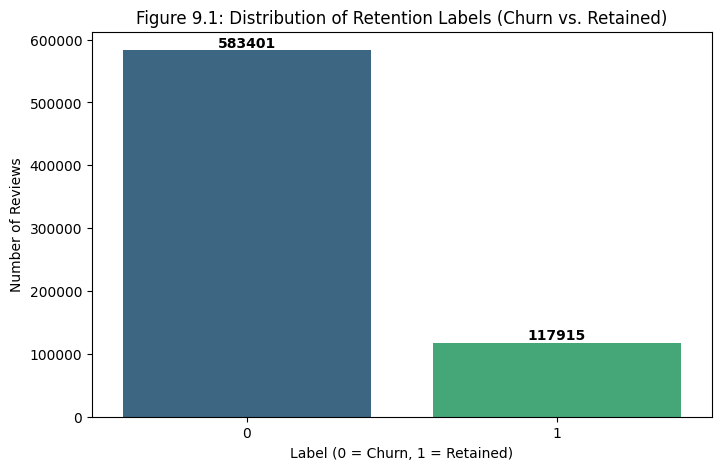

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='retention_label', data=df, palette='viridis')
plt.title('Figure 9.1: Distribution of Retention Labels (Churn vs. Retained)')
plt.xlabel('Label (0 = Churn, 1 = Retained)')
plt.ylabel('Number of Reviews')
# Add counts on top of bars
for i, count in enumerate(df['retention_label'].value_counts().sort_index()):
    plt.text(i, count + 5000, str(count), ha='center', fontweight='bold')
plt.show()

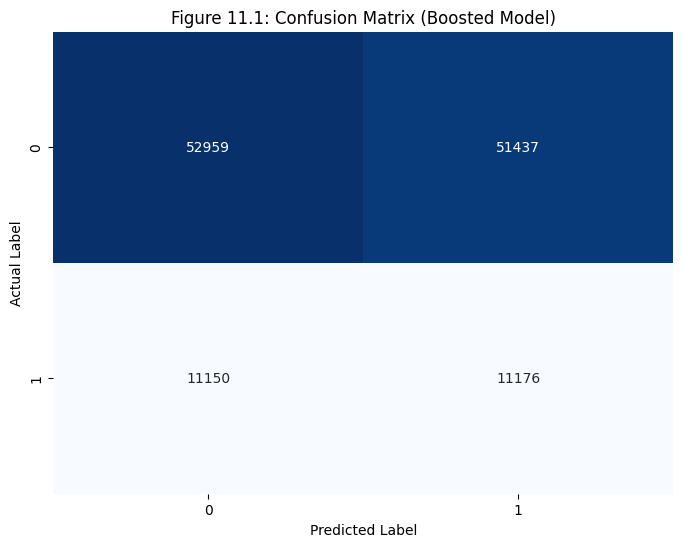

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_boosted.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Figure 11.1: Confusion Matrix (Boosted Model)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Then save your files there
df.to_csv('/content/drive/MyDrive/thesis_data.csv', index=False)
import numpy as np
np.save('/content/drive/MyDrive/X_pca.npy', X_pca)

Mounted at /content/drive
